# Jet Pt distributions and hypothetical Russell weights

**Distribution-only analysis. No classifier changes, model imports, or training.**

Source: the local HLS4ML LHC jet 150-particle train and `val` archives. `Pt` is the
jet-level `jets` column named **`j_pt`** (GeV), not constituent `j1_pt`, `j_ptfrac`, or
`j1_ptrel`. Labels are the five one-hot columns `j_g, j_q, j_w, j_z, j_t`.
There is no native single binary target. We show **five separately labelled one-vs-rest
(OvR) diagnostics**, consistent with the project's evaluation convention; each target
class is signal (`y=1`) and the other four are background (`y=0`). These are five
alternative hypothetical binary assignments, not a combined multiclass weight policy.
Russell's intended binary grouping remains to be confirmed.

The loader sorts HDF5 filenames and retains row order within each file. Constituent
sorting/truncation does not reorder jets. See `../bnhgq2/train.py:load_train_data` and
`train`, `../bnhgq2/data.py:CLASS_LABELS`, and `../run_stage.py` (default seed 1).
The selected R14 config supplies the 0.20 internal validation fraction.

- **full_dataset_diagnostic**: every row of the available train archive plus the
  held-out `val` archive. This includes held-out labels and is for comparison only.
- **training_only_seed1**: the last 80% of `default_rng(1).permutation(N_train_archive)`;
  the first 20% are internal validation. This reproduces the trainer's split, without
  loading features or calling training. Other training seeds require regenerated weights.
- The source archive named `val` is the project's independent **ROC-test** sample;
  it is not the internal validation subset. `DATASET.md` predates the local train download.

“Full” means all HDF5 members in the two available archives, not an assertion that
other upstream archives exist or are included. Filename coverage is checked against
both local tarballs. Jet identities are `(archive_split, filename, row_index)`; no
cross-archive event ID is stored/checked here.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, tarfile, platform, importlib.metadata
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import h5py
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

# Run from this notebook's directory or anywhere beneath the research root.
# Override BNJETTAG_REPO / BNJETTAG_DATA_ROOT when relocating the data.
if os.environ.get("BNJETTAG_REPO"):
    ROOT = Path(os.environ["BNJETTAG_REPO"]).expanduser().resolve()
else:
    ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "bnjettag/code/hgq2/sample_weighting/LOG.md").is_file())
HERE = ROOT / "bnjettag/code/hgq2/sample_weighting"
DATA_ROOT = Path(os.environ.get("BNJETTAG_DATA_ROOT", str(ROOT / "data"))).expanduser().resolve()
OUT = HERE / "outputs"
OUT.mkdir(exist_ok=True)
CONFIG = ROOT / "bnjettag/code/hgq2/configs/r14-l1x3-n16-w1a8.json"
config = json.loads(CONFIG.read_text())
SEED = 1  # run_stage.py default; not a claim that every historical run used seed 1
VALIDATION_FRACTION = float(config["train"]["validation_split"])
CLASS_LABELS = ["j_g", "j_q", "j_w", "j_z", "j_t"]
N_BINS, OFFSET = 100, 0.5
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "font.size": 11})

def sha256_bytes(b):
    return hashlib.sha256(b).hexdigest()

def array_hash(a):
    return sha256_bytes(np.ascontiguousarray(a).tobytes())

settings = {
    "analysis": "distribution only; full_dataset_diagnostic and training_only_seed1",
    "seed": SEED, "validation_fraction": VALIDATION_FRACTION,
    "classes": CLASS_LABELS, "binary_mapping": "each class versus the other four, separately",
    "pt_column": "j_pt", "pt_unit": "GeV", "log": "numpy.log (natural logarithm)",
    "n_bins": N_BINS, "offset": OFFSET,
    "edges": "linspace(min(log(Pt)), max(log(Pt)), 101), independently per output split",
    "intervals": "[left,right), except the final bin includes its right edge",
    "ratio": "(signal_count + 0.5) / (background_count + 0.5)",
    "hypothetical_weights": "background 1; signal its bin ratio; no class-factor multiplication",
    "data_root": str(DATA_ROOT), "config": str(CONFIG.relative_to(ROOT)),
    "source_code_sha256": {str(p.relative_to(ROOT)): sha256_bytes(p.read_bytes()) for p in
        [CONFIG, ROOT / "bnjettag/code/hgq2/bnhgq2/train.py",
         ROOT / "bnjettag/code/hgq2/bnhgq2/data.py", ROOT / "bnjettag/code/hgq2/run_stage.py"]},
    "versions": {m: importlib.metadata.version(m) for m in
                 ["numpy", "pandas", "h5py", "matplotlib", "nbformat", "nbclient", "ipykernel", "jupyter_client"]},
    "python": platform.python_version(),
}
print(json.dumps(settings, indent=2))

{
  "analysis": "distribution only; full_dataset_diagnostic and training_only_seed1",
  "seed": 1,
  "validation_fraction": 0.2,
  "classes": [
    "j_g",
    "j_q",
    "j_w",
    "j_z",
    "j_t"
  ],
  "binary_mapping": "each class versus the other four, separately",
  "pt_column": "j_pt",
  "pt_unit": "GeV",
  "log": "numpy.log (natural logarithm)",
  "n_bins": 100,
  "offset": 0.5,
  "edges": "linspace(min(log(Pt)), max(log(Pt)), 101), independently per output split",
  "intervals": "[left,right), except the final bin includes its right edge",
  "ratio": "(signal_count + 0.5) / (background_count + 0.5)",
  "hypothetical_weights": "background 1; signal its bin ratio; no class-factor multiplication",
  "data_root": "/Users/kaiyamaguchi/Downloads/bnjettag-training-results/data",
  "config": "bnjettag/code/hgq2/configs/r14-l1x3-n16-w1a8.json",
  "source_code_sha256": {
    "bnjettag/code/hgq2/configs/r14-l1x3-n16-w1a8.json": "ee44832204f7dcd6ba0354241e9846fa39004767dcbddcd2a49f6814dac

## Read only jet-level data and verify archive coverage
Fail on missing files, invalid Pt, undefined/non-one-hot labels, or feature/jet row-count
mismatches. No rows are silently filtered. Per-file hashes cover the used Pt and label
arrays (including `j_undef`), not unrelated images/constituents. File sizes and columns are
recorded for provenance. Tarball scanning verifies member names and sizes without extracting.

In [2]:
manifest = []
archive_checks = []
arrays = {}
for archive_split in ("train", "val"):
    files = sorted((DATA_ROOT / archive_split).glob("*.h5"))
    assert files, f"Missing {archive_split} HDF5 data"
    archive = DATA_ROOT / f"hls4ml_LHCjet_150p_{archive_split}.tar.gz"
    assert archive.is_file(), f"Archive required for completeness check: {archive}"
    with tarfile.open(archive, "r:gz") as tf:
        members = [(Path(m.name).name, m.size) for m in tf
                   if m.isfile() and m.name.endswith(".h5")]
    assert len({name for name, _ in members}) == len(members), "Duplicate archive basenames"
    assert dict(members) == {p.name: p.stat().st_size for p in files}, "Incomplete extraction"
    archive_checks.append({"source_split": archive_split, "archive": str(archive),
                           "h5_members": len(members), "names_and_sizes_match": True})
    pts, labels = [], []
    row_offset = 0
    for file_index, fp in enumerate(files):
        with h5py.File(fp, "r") as hf:
            names = [x.decode() if isinstance(x, bytes) else str(x)
                     for x in hf["jetFeatureNames"][:]]
            assert len(names) == len(set(names))
            columns = [names.index(n) for n in ["j_pt", *CLASS_LABELS, "j_undef"]]
            jets = hf["jets"][:]
            assert len(jets) == hf["jetConstituentList"].shape[0]
            pt = jets[:, columns[0]].astype(np.float64)
            raw_labels = jets[:, columns[1:]]
            assert np.isfinite(pt).all() and (pt > 0).all(), fp
            assert np.isin(raw_labels, [0, 1]).all(), fp
            assert (raw_labels[:, -1] == 0).all(), fp
            assert (raw_labels[:, :-1].sum(axis=1) == 1).all(), fp
            y = raw_labels[:, :-1].astype(np.uint8)
            manifest.append({"source_split": archive_split, "file_index": file_index,
                "file": str(fp.relative_to(DATA_ROOT)), "file_bytes": fp.stat().st_size,
                "rows": len(pt), "source_row_start": row_offset,
                "source_row_stop_exclusive": row_offset + len(pt),
                "pt_column_index": columns[0], "label_column_indices": json.dumps(columns[1:-1]),
                "pt_float64_sha256": array_hash(pt),
                "labels_with_undef_raw_sha256": array_hash(raw_labels)})
            pts.append(pt); labels.append(y); row_offset += len(pt)
    arrays[archive_split] = (np.concatenate(pts), np.concatenate(labels))
    print(f"Source split={archive_split}: {len(files)} files, {row_offset:,} valid jets")
manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(OUT / "source_split_file_manifest.csv", index=False)
display(pd.DataFrame(archive_checks))

Source split=train: 62 files, 620,000 valid jets
Source split=val: 26 files, 260,000 valid jets


,source_split,archive,h5_members,names_and_sizes_match
0,train,/Users/kaiyamaguchi/Downloads/bnjettag-trainin...,62,True
1,val,/Users/kaiyamaguchi/Downloads/bnjettag-trainin...,26,True


In [3]:
train_pt, train_y = arrays["train"]
test_pt, test_y = arrays["val"]
permutation = np.random.default_rng(SEED).permutation(len(train_pt))
nval = int(len(train_pt) * VALIDATION_FRACTION)
validation_indices, training_indices = permutation[:nval], permutation[nval:]
assert np.array_equal(np.sort(np.r_[validation_indices, training_indices]), np.arange(len(train_pt)))
assert np.intersect1d(validation_indices, training_indices).size == 0
splits = {
    "full_dataset_diagnostic": (np.r_[train_pt, test_pt], np.concatenate([train_y, test_y])),
    f"training_only_seed{SEED}": (train_pt[training_indices], train_y[training_indices]),
}
split_rows = []
for name, (pt, y) in {
    "source_train_archive": arrays["train"],
    f"internal_validation_seed{SEED}": (train_pt[validation_indices], train_y[validation_indices]),
    "heldout_roc_test_source_val": arrays["val"], **splits,
}.items():
    split_rows.append({"dataset_split": name, "n_jets": len(pt),
        "pt_min_GeV": pt.min(), "pt_max_GeV": pt.max(),
        **{label: int(y[:, i].sum()) for i, label in enumerate(CLASS_LABELS)}})
split_df = pd.DataFrame(split_rows)
split_df.to_csv(OUT / "dataset_split_inventory.csv", index=False, float_format="%.17g")
settings["split_index_sha256"] = {
    f"training_only_seed{SEED}": array_hash(training_indices.astype("<i8")),
    f"internal_validation_seed{SEED}": array_hash(validation_indices.astype("<i8")),
}
settings["archive_coverage"] = archive_checks
display(split_df)

,dataset_split,n_jets,pt_min_GeV,pt_max_GeV,j_g,j_q,j_w,j_z,j_t
0,source_train_archive,620000,209.007675,3026.289062,124848,120211,124937,124654,125350
1,internal_validation_seed1,124000,273.644043,2759.856689,24894,23809,25018,24997,25282
2,heldout_roc_test_source_val,260000,159.331894,3156.729004,52404,50468,52235,52298,52595
3,full_dataset_diagnostic,880000,159.331894,3156.729004,177252,170679,177172,176952,177945
4,training_only_seed1,496000,209.007675,3026.289062,99954,96402,99919,99657,100068


## Russell's formula, without alteration
Use `np.log(Pt)` and 100 equal-width bins spanning the **selected split's** observed
range. Full-dataset bins never enter the training-only calculation. A zero/zero bin has
ratio 1 due to the 0.5 offset. No clipping, inversion, normalization, or balanced-class
multiplier is applied. The ratio direction is reproduced literally; multiplying signal
by signal/background is not in general a procedure for matching the two Pt distributions.

For reference, binary balanced class factors `N/(2*N_class)` are recorded in the
verification table but **not applied**. Whether Russell intends to combine them is open.

The weight histogram counts jets, including backgrounds at weight 1. These are
hypothetical weights held in memory, not weights passed to a classifier. Bin indices
are computed in the same row order as Pt and labels. The maximum endpoint belongs to
bin 99, following `np.histogram`; we do not clip out-of-range values. A future application
to other data must explicitly choose a policy outside the training Pt range.

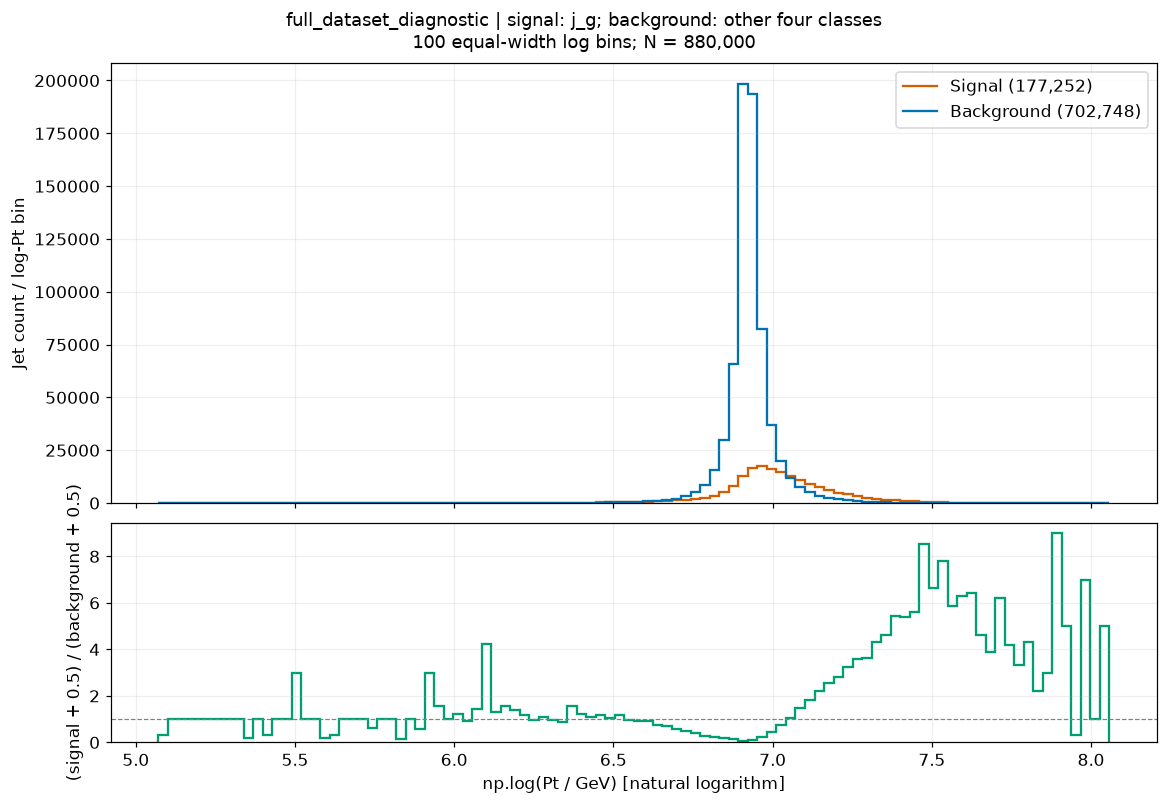

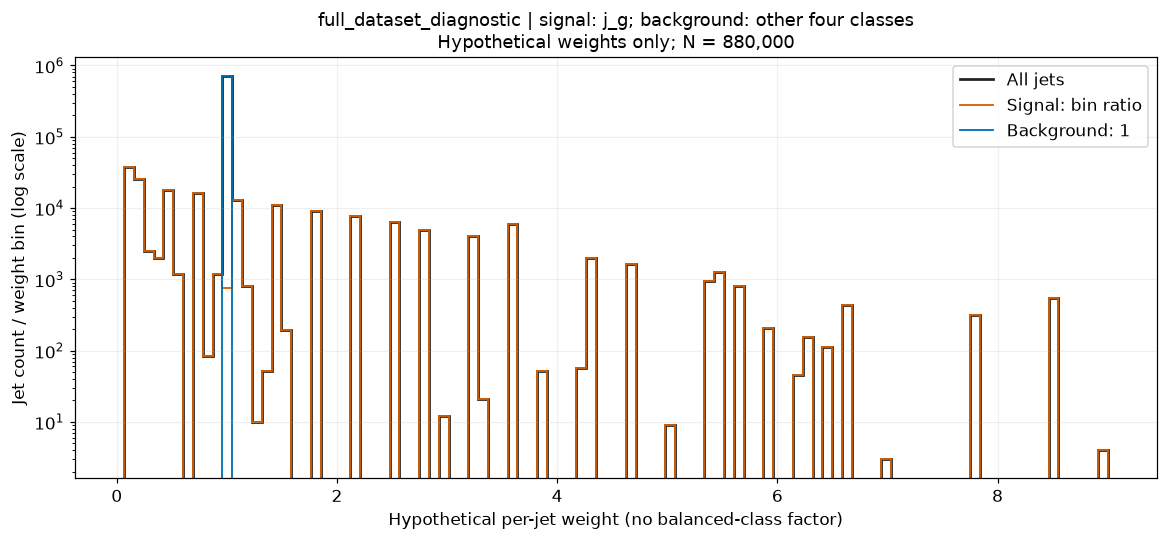

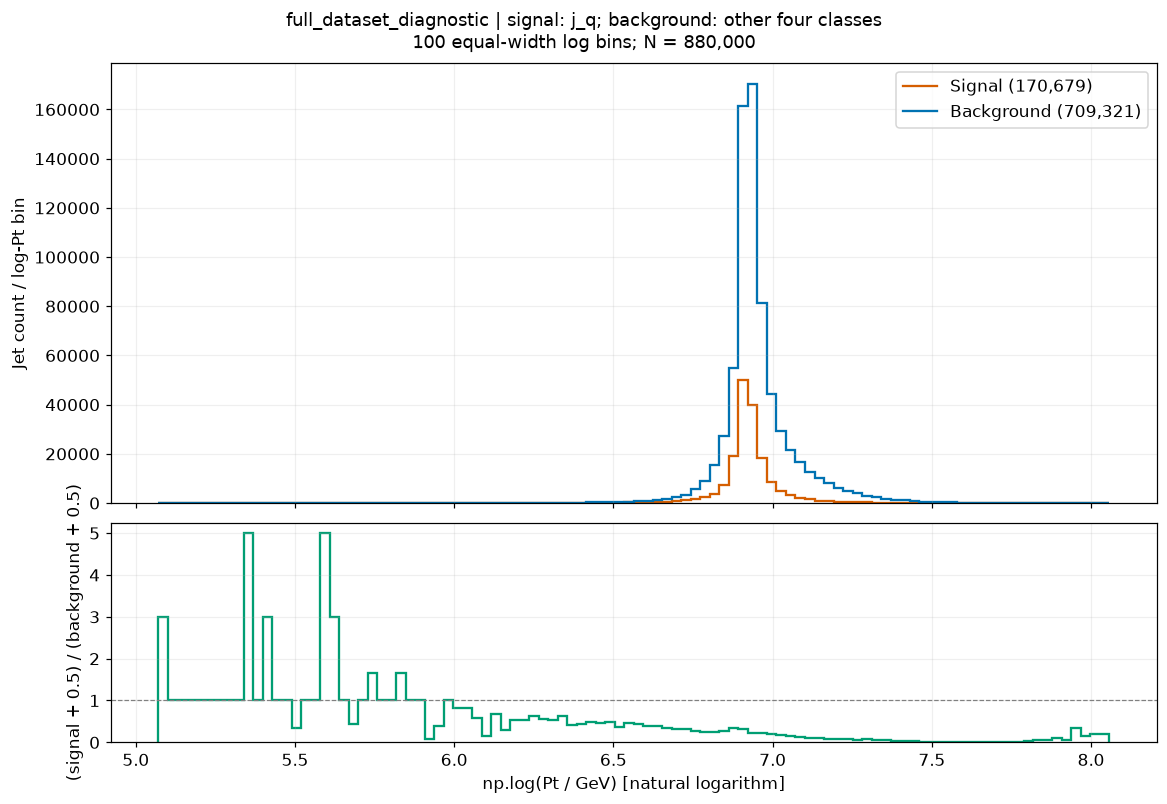

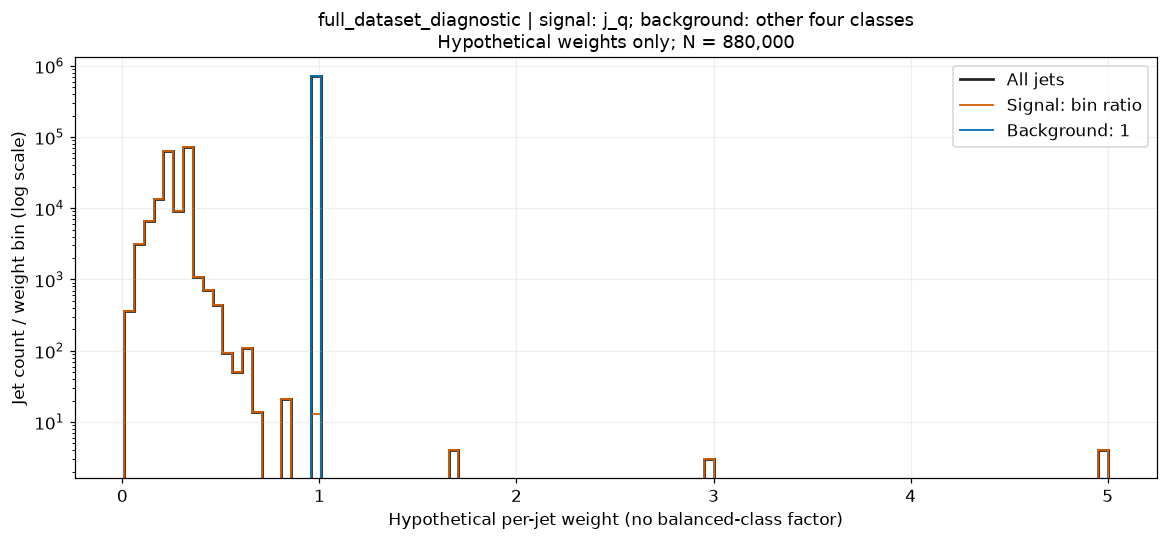

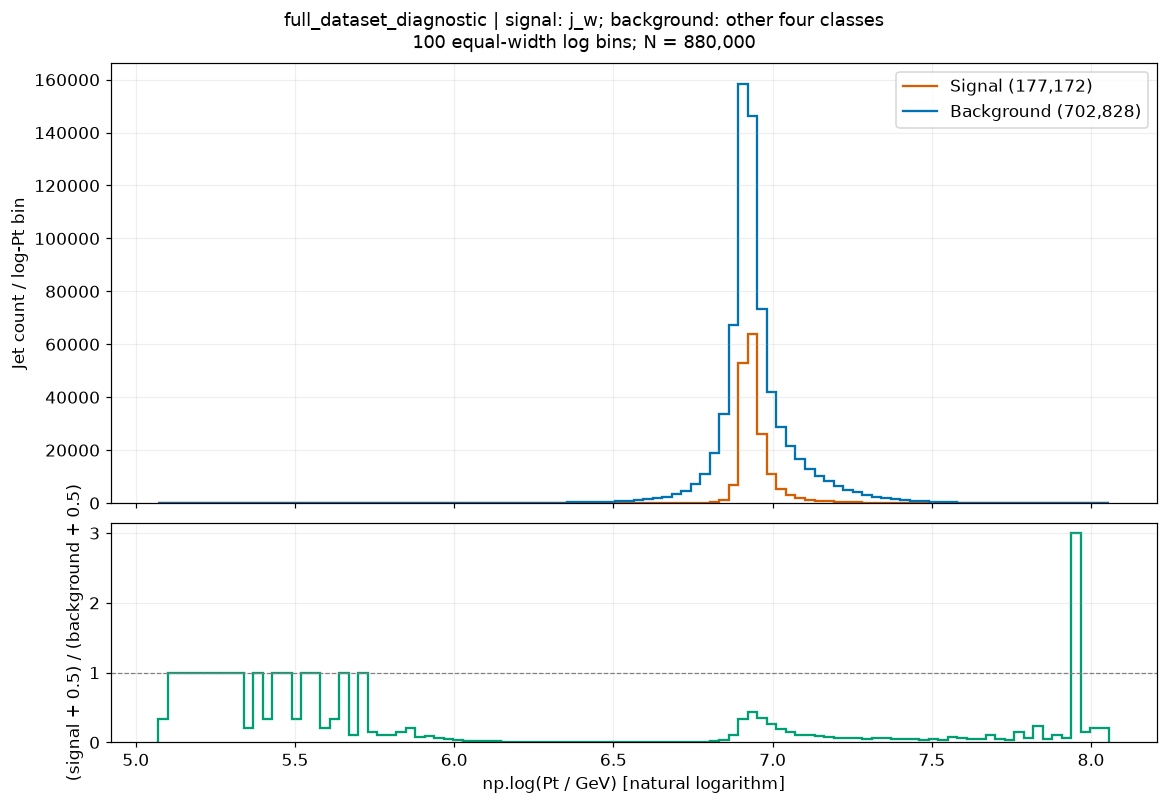

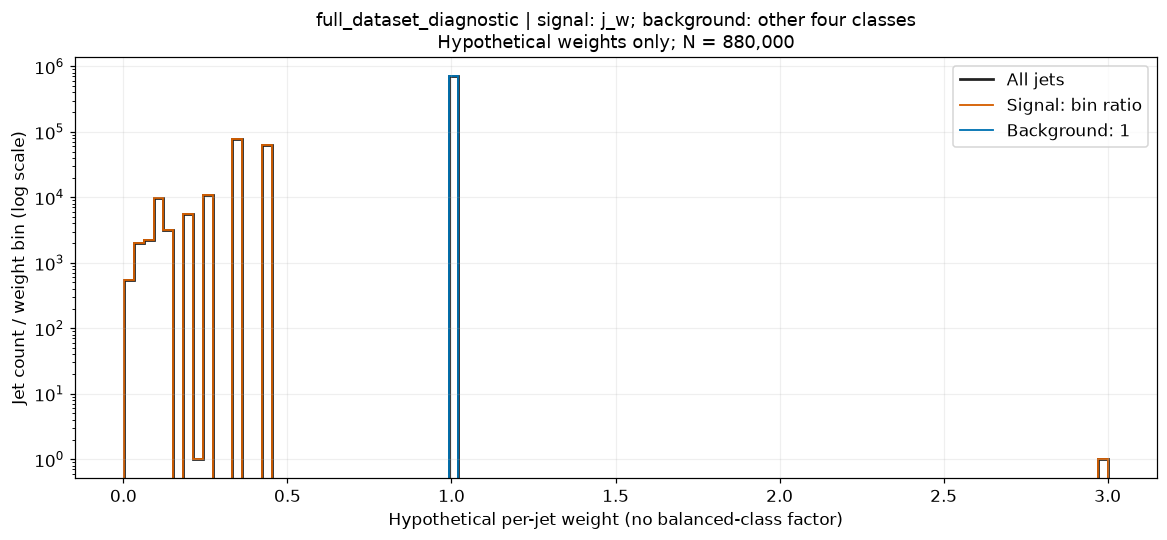

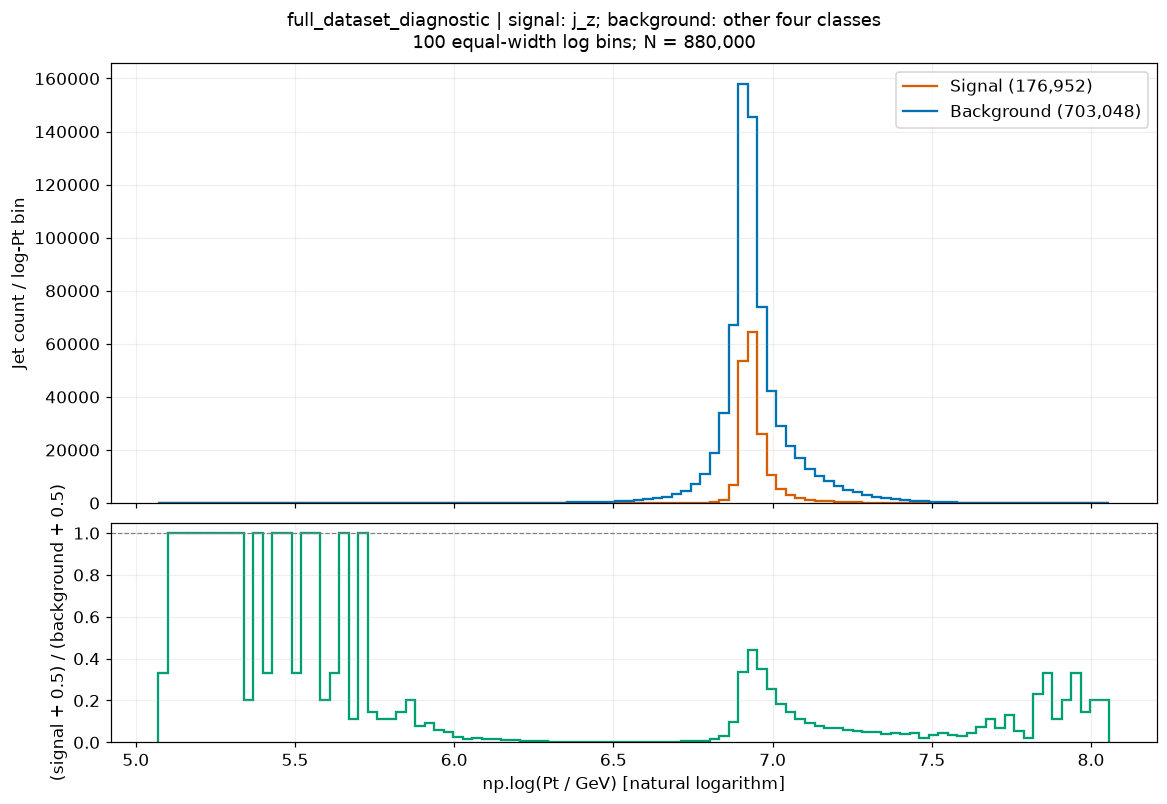

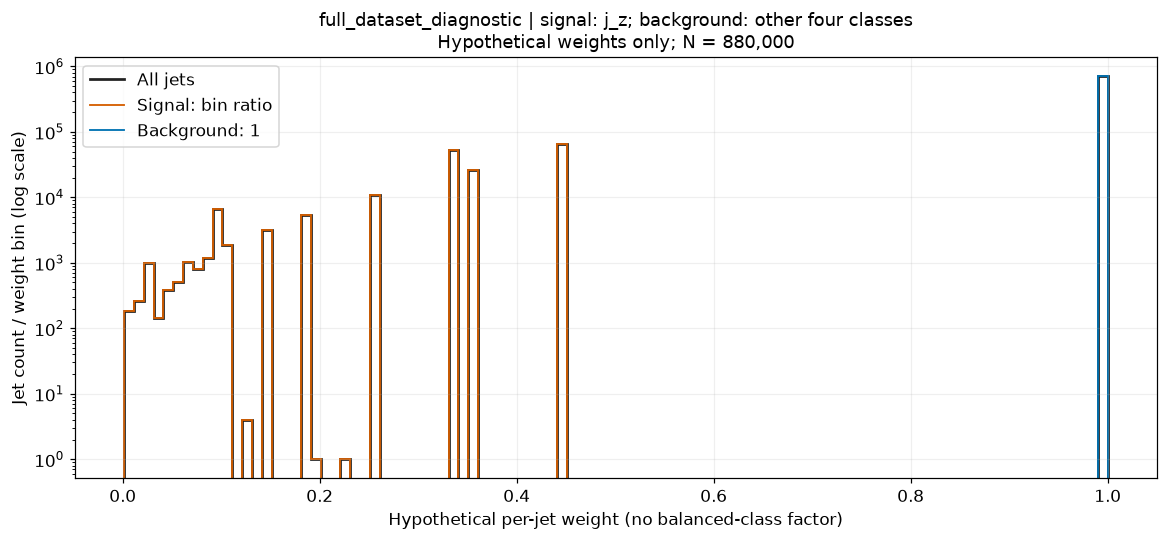

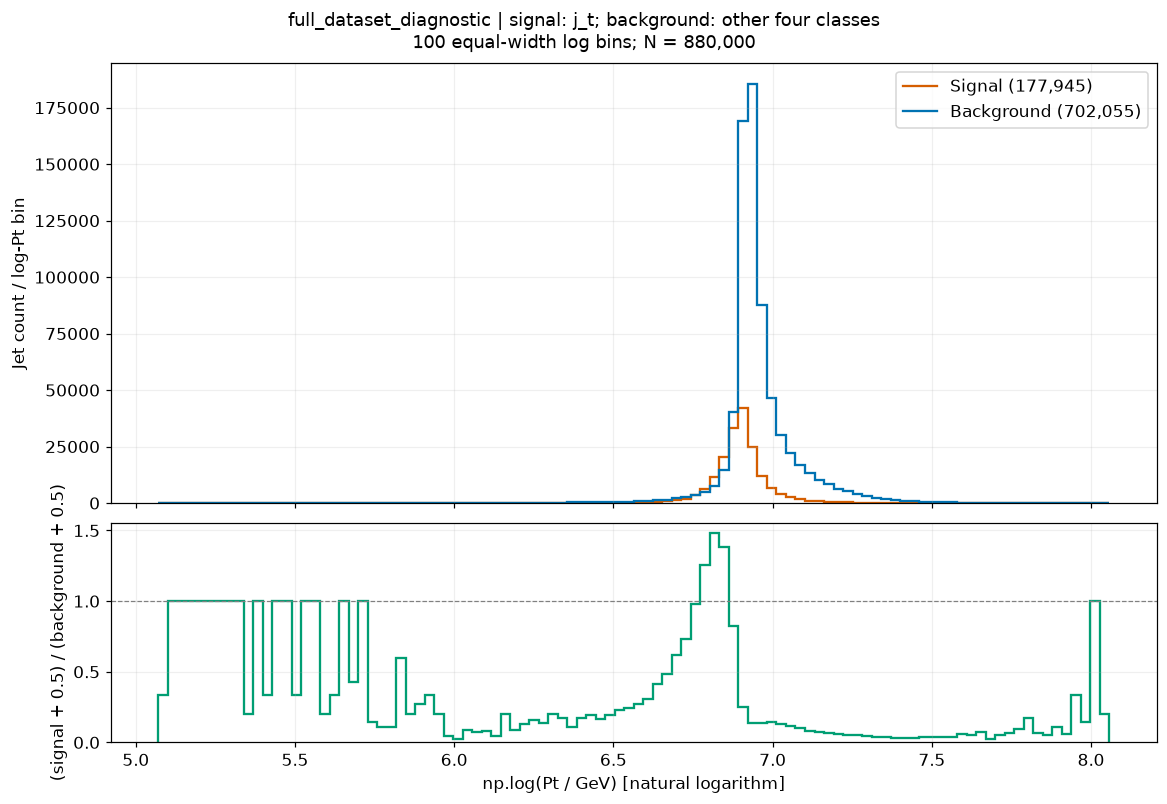

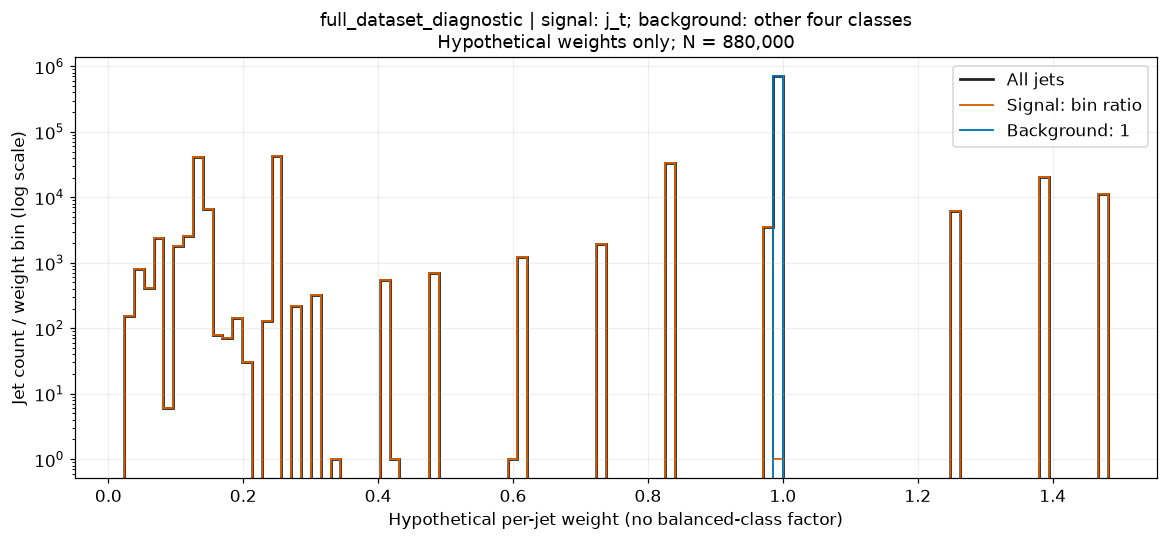

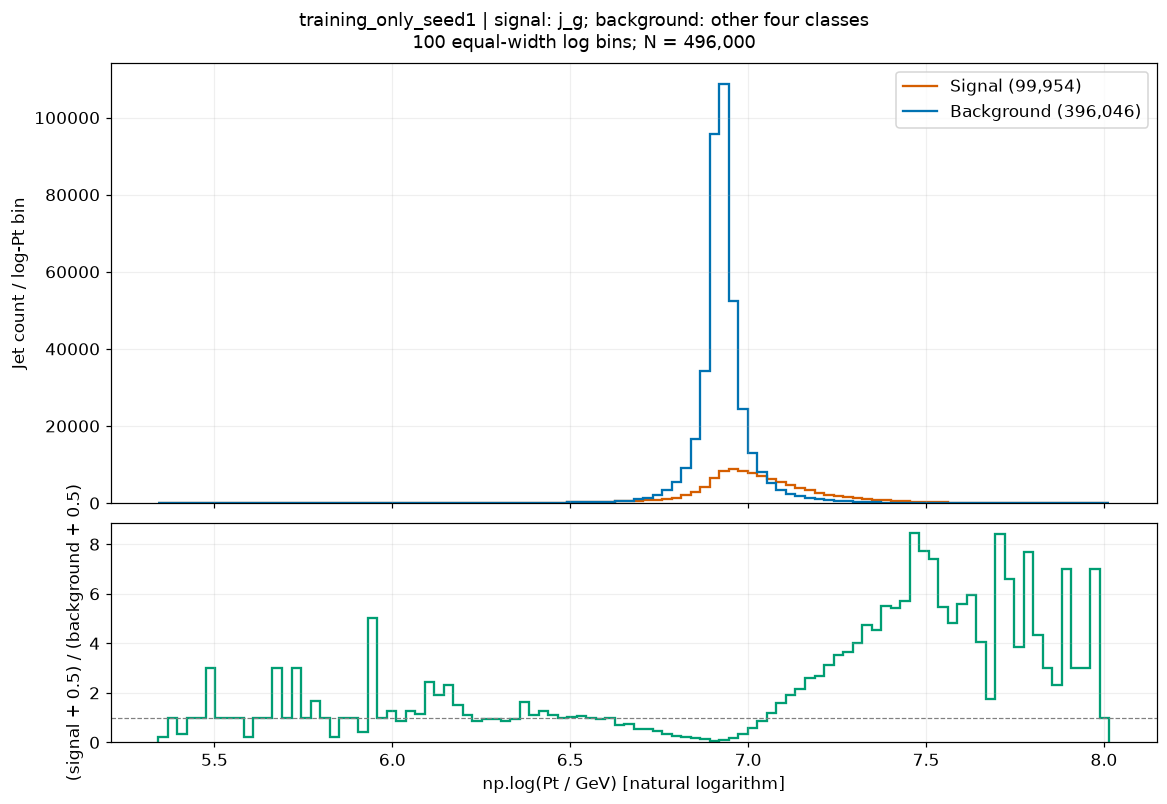

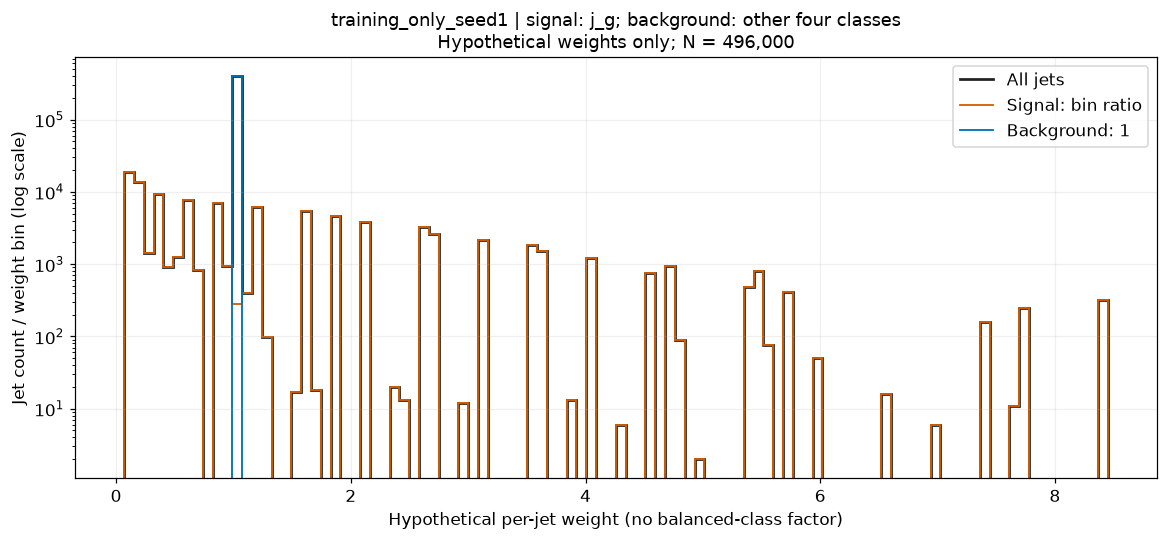

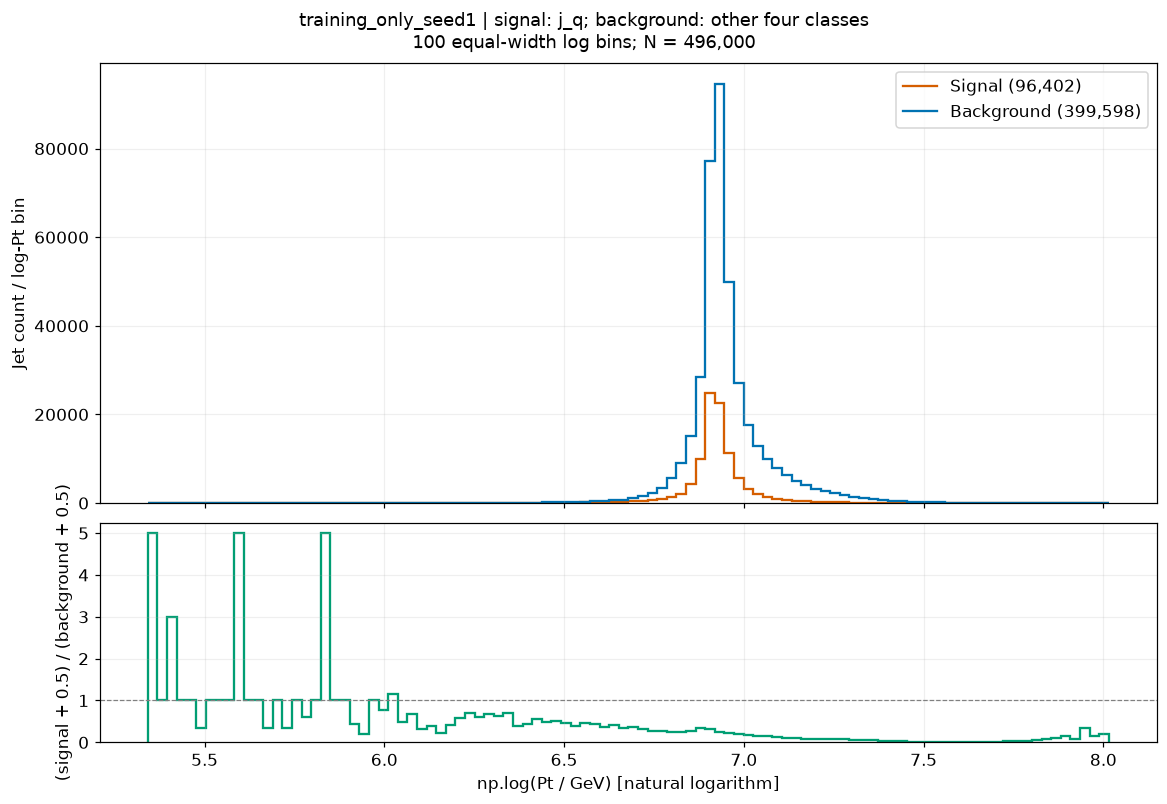

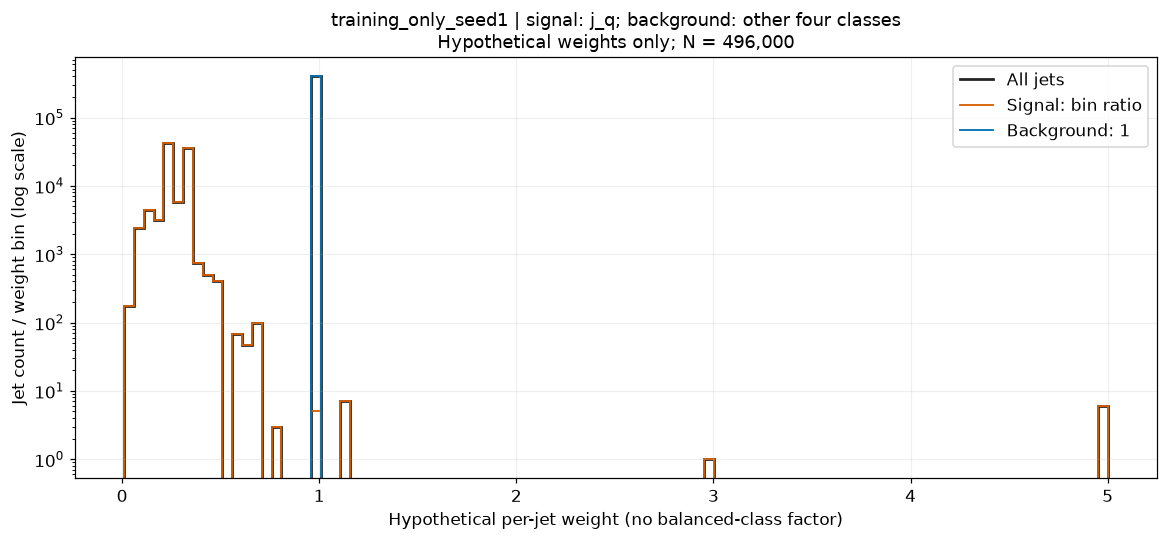

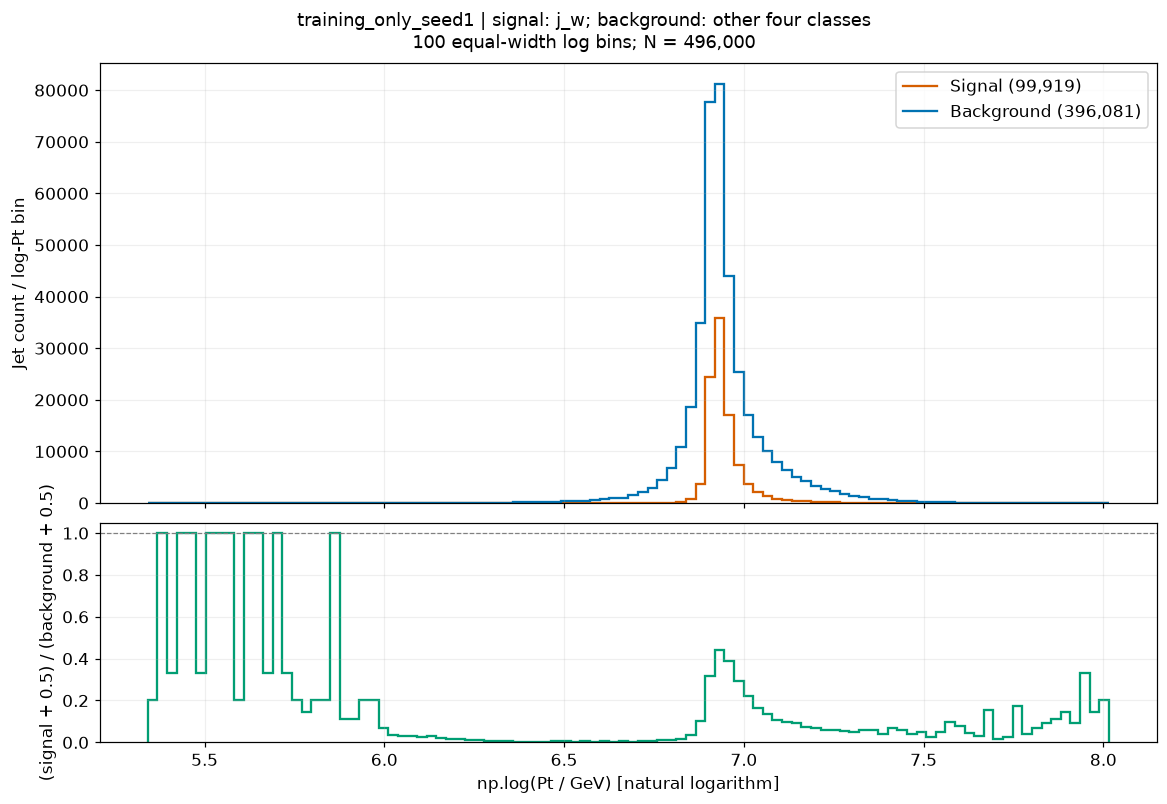

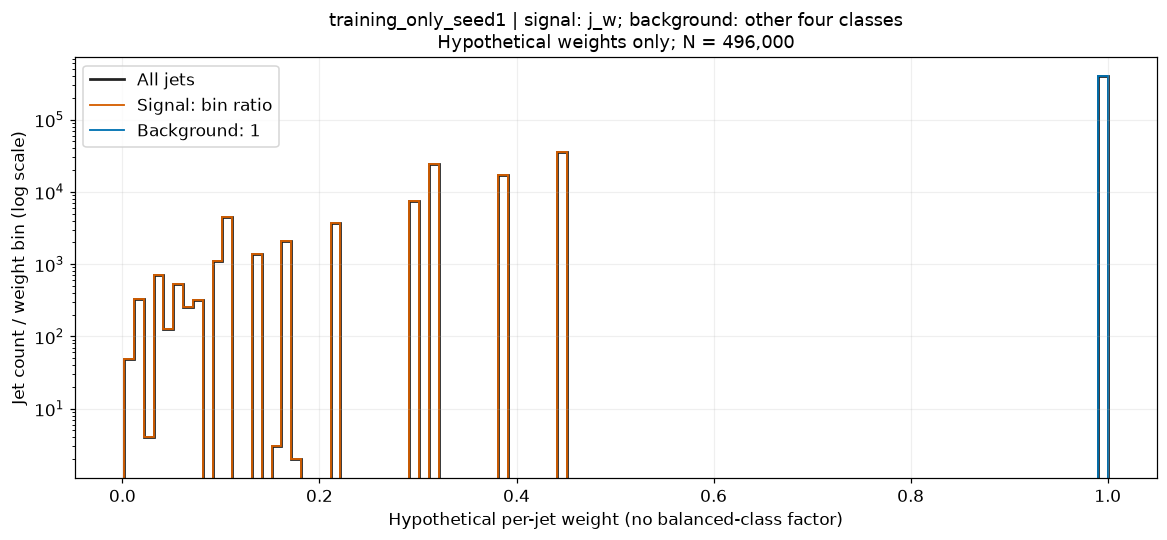

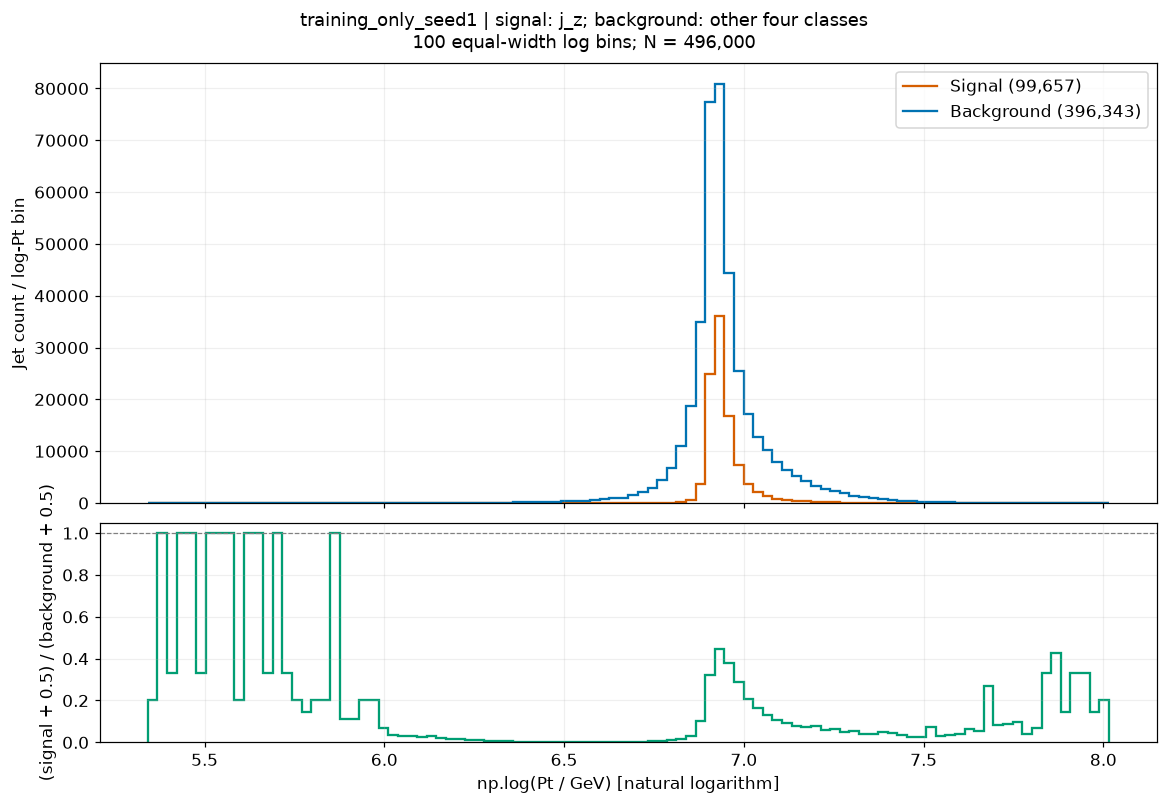

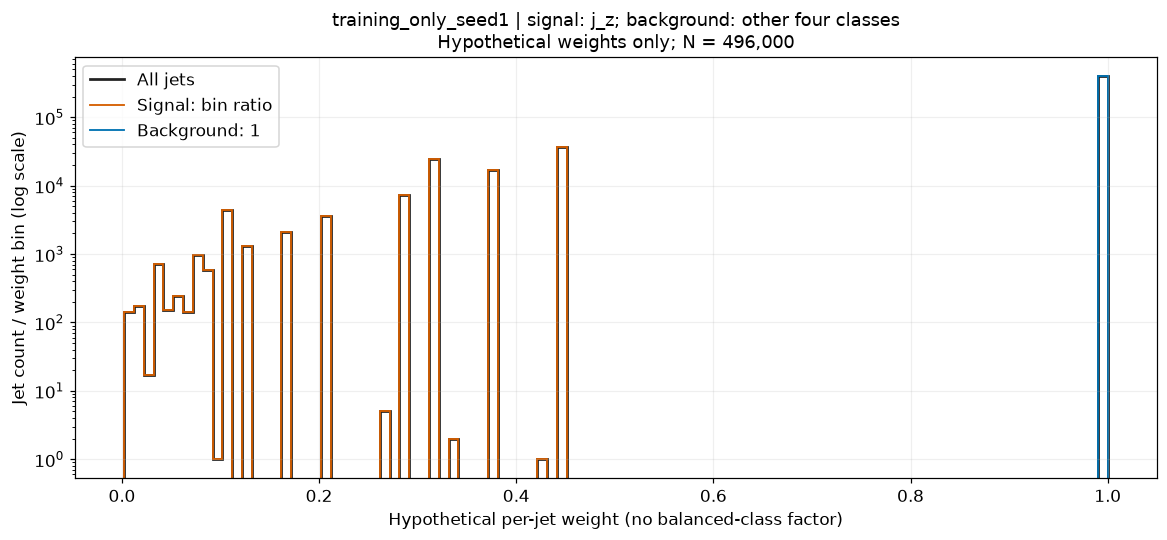

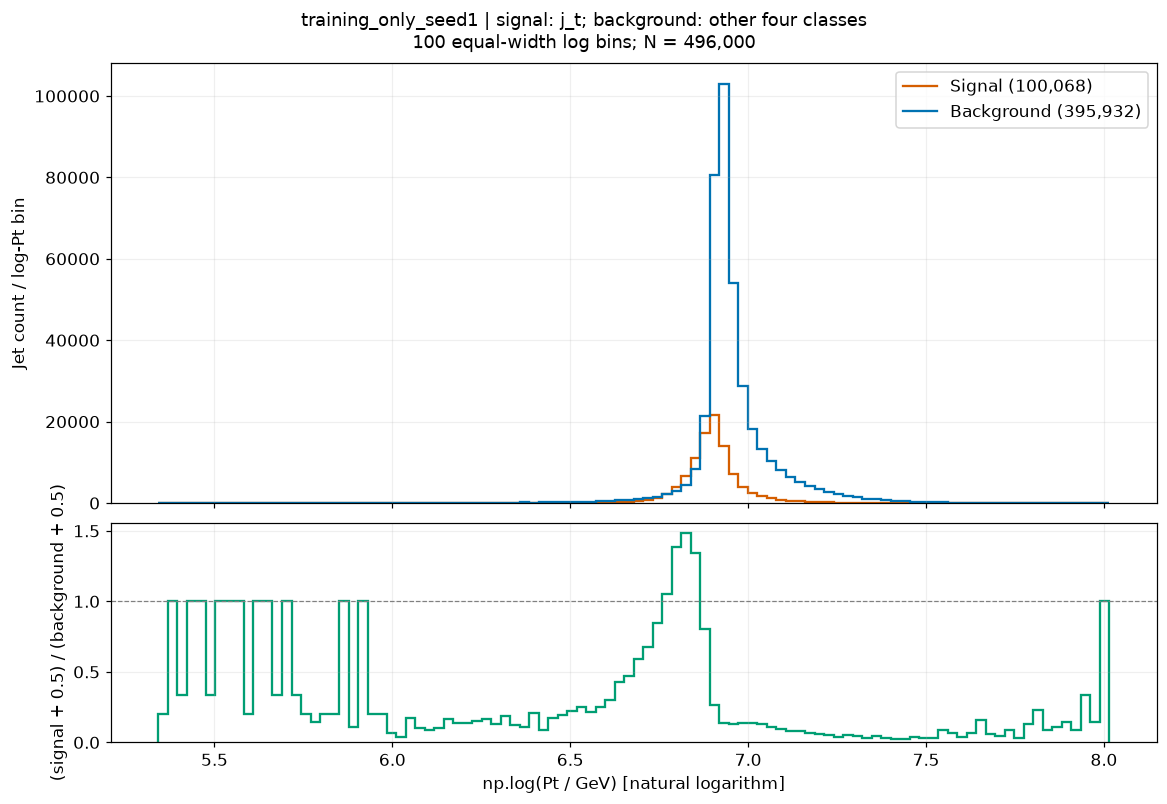

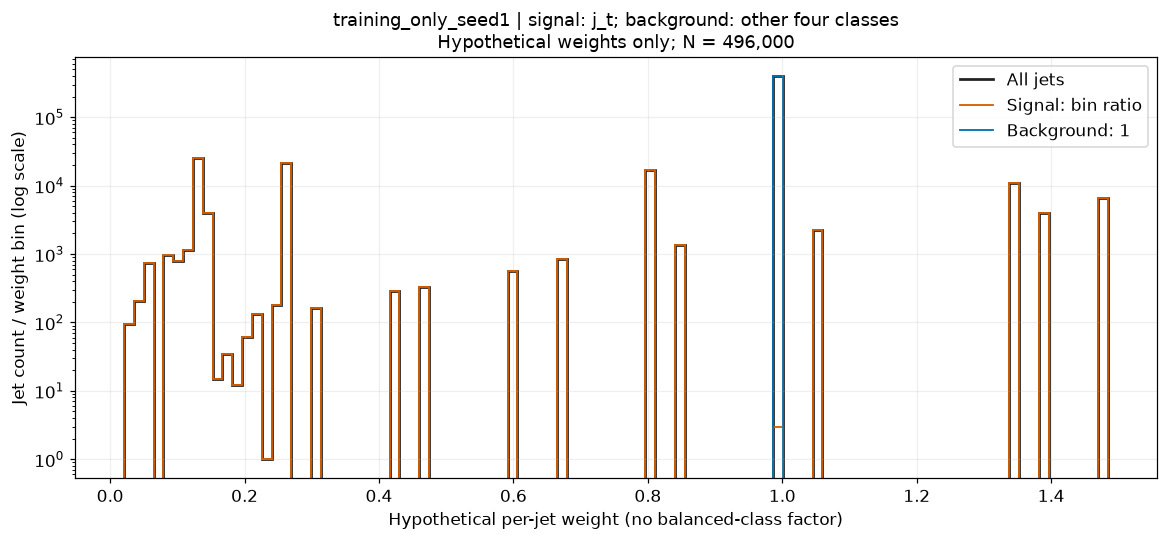

,dataset_split,signal_label,n_jets,signal_count,background_count,bin_count_sum,weight_hist_count_sum,empty_both_bins,zero_background_bins,ratio_min,ratio_max,jet_weight_min,jet_weight_max,balanced_signal_factor_NOT_APPLIED,balanced_background_factor_NOT_APPLIED,count_and_alignment_checks
0,full_dataset_diagnostic,j_g,880000,177252,702748,880000,880000,15,19,0.065688,9.000000,0.065688,9.000000,2.482342,0.626113,PASS
1,full_dataset_diagnostic,j_q,880000,170679,709321,880000,880000,15,20,0.001403,5.000000,0.008451,5.000000,2.577939,0.620312,PASS
2,full_dataset_diagnostic,j_w,880000,177172,702828,880000,880000,15,16,0.001074,3.000000,0.001858,3.000000,2.483462,0.626042,PASS
3,full_dataset_diagnostic,j_z,880000,176952,703048,880000,880000,15,15,0.000491,1.000000,0.001333,1.000000,2.486550,0.625846,PASS
4,full_dataset_diagnostic,j_t,880000,177945,702055,880000,880000,15,15,0.023256,1.481580,0.023256,1.481580,2.472674,0.626732,PASS
5,training_only_seed1,j_g,496000,99954,396046,496000,496000,10,17,0.067588,8.449275,0.067588,8.449275,2.481141,0.626190,PASS
6,training_only_seed1,j_q,496000,96402,399598,496000,496000,10,14,0.002770,5.000000,0.009585,5.000000,2.572561,0.620624,PASS
7,training_only_seed1,j_w,496000,99919,396081,496000,496000,10,10,0.000514,1.000000,0.001633,1.000000,2.482010,0.626135,PASS
8,training_only_seed1,j_z,496000,99657,396343,496000,496000,10,10,0.000934,1.000000,0.002099,1.000000,2.488536,0.625721,PASS
9,training_only_seed1,j_t,496000,100068,395932,496000,496000,10,10,0.020665,1.484041,0.020665,1.484041,2.478315,0.626370,PASS


In [4]:
def bin_indices(log_pt, edges):
    assert np.isfinite(log_pt).all()
    assert (log_pt >= edges[0]).all() and (log_pt <= edges[-1]).all()
    idx = np.searchsorted(edges, log_pt, side="right") - 1
    idx[log_pt == edges[-1]] = len(edges) - 2
    assert ((0 <= idx) & (idx < len(edges) - 1)).all()
    return idx

# Check first/internal/final edge semantics independently of the data distribution.
probe_edges = np.linspace(1.0, 3.0, 101)
probe = np.array([probe_edges[0], probe_edges[1], probe_edges[-1]])
assert np.array_equal(bin_indices(probe, probe_edges), [0, 1, 99])
assert np.array_equal(np.bincount(bin_indices(probe, probe_edges), minlength=100),
                      np.histogram(probe, bins=probe_edges)[0])

verification = []
artifacts = []
for split_name, (pt, onehot) in splits.items():
    dest = OUT / split_name
    dest.mkdir(exist_ok=True)
    log_pt = np.log(pt)
    edges = np.linspace(log_pt.min(), log_pt.max(), N_BINS + 1)
    assert np.allclose(np.diff(edges), np.diff(edges)[0], rtol=1e-12, atol=1e-15)
    indices = bin_indices(log_pt, edges)
    total_counts = np.histogram(log_pt, bins=edges)[0]
    assert total_counts.sum() == len(pt)
    assert np.array_equal(total_counts, np.bincount(indices, minlength=N_BINS))
    for class_index, signal_label in enumerate(CLASS_LABELS):
        target = f"{signal_label}_vs_rest"
        signal = onehot[:, class_index].astype(bool)
        background = ~signal
        sc = np.histogram(log_pt[signal], bins=edges)[0]
        bc = np.histogram(log_pt[background], bins=edges)[0]
        assert sc.sum() == signal.sum() and bc.sum() == background.sum()
        assert np.array_equal(sc + bc, total_counts)
        assert np.array_equal(sc, np.bincount(indices[signal], minlength=N_BINS))
        assert np.array_equal(bc, np.bincount(indices[background], minlength=N_BINS))
        ratio = (sc + OFFSET) / (bc + OFFSET)
        weights = np.where(signal, ratio[indices], 1.0)
        assert weights.shape == pt.shape == signal.shape
        assert np.isfinite(weights).all() and (weights > 0).all()
        assert (weights[background] == 1).all()
        assert np.array_equal(weights[signal], ratio[indices[signal]])
        assert np.isclose(weights.sum(), background.sum() + np.dot(sc, ratio))
        table = pd.DataFrame({
            "dataset_split": split_name, "signal_label": signal_label,
            "background_labels": ",".join(c for c in CLASS_LABELS if c != signal_label),
            "bin_index": np.arange(N_BINS), "log_pt_left": edges[:-1],
            "log_pt_right": edges[1:], "pt_left_GeV": np.exp(edges[:-1]),
            "pt_right_GeV": np.exp(edges[1:]),
            "right_edge_inclusive": np.arange(N_BINS) == N_BINS - 1,
            "signal_count": sc, "background_count": bc, "ratio": ratio})
        csv_path = dest / f"{split_name}__{target}__bins.csv"
        table.to_csv(csv_path, index=False, float_format="%.17g")
        check = pd.read_csv(csv_path, float_precision="round_trip")
        assert len(check) == N_BINS
        assert int(check.signal_count.sum() + check.background_count.sum()) == len(pt)
        assert np.array_equal(check.ratio.to_numpy(), ratio)

        title = f"{split_name} | signal: {signal_label}; background: other four classes"
        fig, axes = plt.subplots(2, 1, figsize=(10.5, 7.2), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1]}, layout="constrained")
        axes[0].stairs(sc, edges, label=f"Signal ({signal.sum():,})", color="#d55e00", linewidth=1.5)
        axes[0].stairs(bc, edges, label=f"Background ({background.sum():,})", color="#0072b2", linewidth=1.5)
        axes[0].set_ylabel("Jet count / log-Pt bin")
        axes[0].legend()
        axes[1].stairs(ratio, edges, color="#009e73", linewidth=1.5)
        axes[1].axhline(1, color="gray", linestyle="--", linewidth=0.8)
        axes[1].set_ylabel("(signal + 0.5) / (background + 0.5)")
        axes[1].set_xlabel("np.log(Pt / GeV) [natural logarithm]")
        for ax in axes: ax.grid(alpha=0.2)
        fig.suptitle(title + f"\n100 equal-width log bins; N = {len(pt):,}", fontsize=12)
        count_path = dest / f"{split_name}__{target}__counts_ratio.png"
        fig.savefig(count_path)
        display(fig); plt.close(fig)

        # One common linear weight-bin grid includes every hypothetical weight.
        weight_edges = np.histogram_bin_edges(weights, bins=100)
        sh = np.histogram(weights[signal], bins=weight_edges)[0]
        bh = np.histogram(weights[background], bins=weight_edges)[0]
        assert sh.sum() == signal.sum() and bh.sum() == background.sum()
        assert (sh + bh).sum() == len(pt)
        fig, ax = plt.subplots(figsize=(10.5, 4.8), layout="constrained")
        ax.stairs(sh + bh, weight_edges, label="All jets", color="#222222", linewidth=1.8)
        ax.stairs(sh, weight_edges, label="Signal: bin ratio", color="#d55e00", linewidth=1.2)
        ax.stairs(bh, weight_edges, label="Background: 1", color="#0072b2", linewidth=1.2)
        ax.set_yscale("log")
        ax.set_xlabel("Hypothetical per-jet weight (no balanced-class factor)")
        ax.set_ylabel("Jet count / weight bin (log scale)")
        ax.set_title(title + f"\nHypothetical weights only; N = {len(pt):,}", fontsize=12)
        ax.legend(); ax.grid(alpha=0.2)
        weight_path = dest / f"{split_name}__{target}__hypothetical_weights.png"
        fig.savefig(weight_path)
        display(fig); plt.close(fig)
        verification.append({"dataset_split": split_name, "signal_label": signal_label,
            "n_jets": len(pt), "signal_count": int(sc.sum()), "background_count": int(bc.sum()),
            "bin_count_sum": int((sc + bc).sum()), "weight_hist_count_sum": int((sh + bh).sum()),
            "empty_both_bins": int(((sc == 0) & (bc == 0)).sum()),
            "zero_background_bins": int((bc == 0).sum()),
            "ratio_min": float(ratio.min()), "ratio_max": float(ratio.max()),
            "jet_weight_min": float(weights.min()), "jet_weight_max": float(weights.max()),
            "balanced_signal_factor_NOT_APPLIED": len(pt) / (2 * signal.sum()),
            "balanced_background_factor_NOT_APPLIED": len(pt) / (2 * background.sum()),
            "count_and_alignment_checks": "PASS"})
        artifacts.append({"dataset_split": split_name, "signal_label": signal_label,
            "table": str(csv_path.relative_to(HERE)),
            "count_ratio_figure": str(count_path.relative_to(HERE)),
            "weight_figure": str(weight_path.relative_to(HERE))})
verification_df = pd.DataFrame(verification)
verification_df.to_csv(OUT / "full_and_training_only_verification.csv", index=False, float_format="%.17g")
display(verification_df)

In [5]:
settings["executed_at_utc"] = datetime.now(timezone.utc).isoformat()
settings["verification"] = "All assertions passed: archive coverage, labels/Pt, split partition, bin totals, row alignment, histogram totals, CSV round trip."
settings["artifacts"] = artifacts
(OUT / "full_and_training_only_run_settings.json").write_text(json.dumps(settings, indent=2) + "\n")
# Exact environment used, suitable for reconstructing this analysis-only environment.
requirements = "\n".join(f"{name}=={version}" for name, version in settings["versions"].items()) + "\n"
(HERE / "requirements-analysis.txt").write_text(requirements)
print("Split-labelled artifacts (relative to the notebook):")
display(pd.DataFrame(artifacts))
print("PASS: all verification assertions; no classifier imported or training run.")

Split-labelled artifacts (relative to the notebook):


,dataset_split,signal_label,table,count_ratio_figure,weight_figure
0,full_dataset_diagnostic,j_g,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...
1,full_dataset_diagnostic,j_q,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...
2,full_dataset_diagnostic,j_w,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...
3,full_dataset_diagnostic,j_z,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...
4,full_dataset_diagnostic,j_t,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...,outputs/full_dataset_diagnostic/full_dataset_d...
5,training_only_seed1,j_g,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...
6,training_only_seed1,j_q,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...
7,training_only_seed1,j_w,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...
8,training_only_seed1,j_z,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...
9,training_only_seed1,j_t,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...,outputs/training_only_seed1/training_only_seed...


PASS: all verification assertions; no classifier imported or training run.


## Reproduce and interpret
From the research root, with the analysis requirements installed, execute:

```bash
python bnjettag/code/hgq2/sample_weighting/execute_notebook.py
```

The notebook is executable independently via Jupyter **Restart Kernel and Run All**.
`BNJETTAG_REPO` and `BNJETTAG_DATA_ROOT` can relocate the research tree and archive data.
Outputs are deterministic apart from execution time and notebook display metadata.
The settings JSON records dependency versions, input-array hashes, source hashes, seed,
archive coverage, and artifact paths. It does not claim exact visual agreement with
Russell's figures: his original dataset, binary grouping, and axis formatting are not
available in the study log. Linear count/ratio axes and a log-count weight histogram
are explicitly labelled. No performance or training claim follows from these plots.

Next: review these distributions with Russell; confirm the signal/background grouping,
ratio direction/objective, whether to multiply balanced class factors, sparse-bin
stability, and the out-of-training-range policy before defining a training experiment.